In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
# let's have a look at the data scrapted from web of science

In [3]:
# there's considerable range in our bs values; this may actually be an informative about
# the different entitites[fields, countries, genders, institutions, journals ..]
# for instance, we can see that the minimum index for neuroscience is more than double the minimum in physics

In [4]:
neuro_df = pd.read_csv('/Users/mococomac/PycharmProjects/bsFactor/fields/neuroscience/outputs/neuroscience_bs_indices.csv')
physi_df = pd.read_csv('/Users/mococomac/PycharmProjects/bsFactor/fields/physics/outputs/physics_bs_indices.csv')

In [5]:
print('there are ' + str(neuro_df.shape[0]) + ' neuroscience indices, with values ranging from ' +str(neuro_df['BS_Index'].min()) + ' to ' + str(neuro_df['BS_Index'].max()) + ', from ' + str(len(neuro_df["Country"].unique())) + ' countries')
print('there are ' + str(physi_df.shape[0]) + ' physics indices, with values ranging from ' +str(physi_df['BS_Index'].min()) + ' to ' + str(physi_df['BS_Index'].max())+ ', from ' + str(len(physi_df["Country"].unique())) + ' countries')

there are 174025 neuroscience indices, with values ranging from 0.025694244604317 to 132.964, from 37 countries
there are 55159 physics indices, with values ranging from 0.0106737012987013 to 127.39, from 13 countries


[Text(0.5, 1.0, 'median indices across years, regardless of field')]

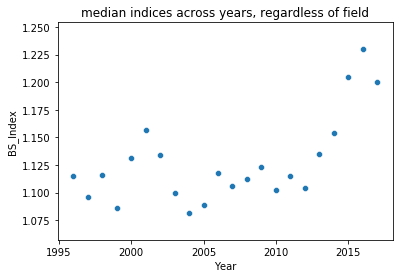

In [6]:
# quick scatterplot to see how the indices have evolved across years
sns.scatterplot(pd.concat([neuro_df,physi_df]).groupby(['Year'])['BS_Index'].median()).set(title='median indices across years, regardless of field')

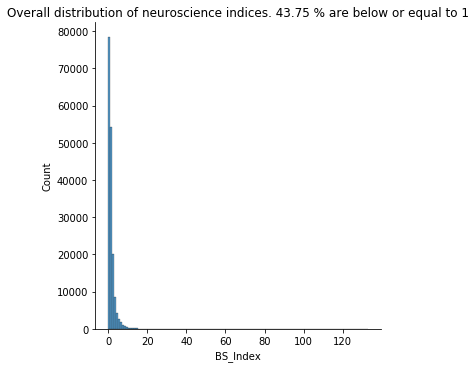

In [7]:
# let's plot some histograms

neuro_virtuous = np.round((neuro_df['BS_Index']<=1).sum()/len(neuro_df['BS_Index'])*100,2)

sns.displot(neuro_df, x="BS_Index",binwidth=1).set(title='Overall distribution of neuroscience indices. ' + str(neuro_virtuous) + ' % are below or equal to 1')

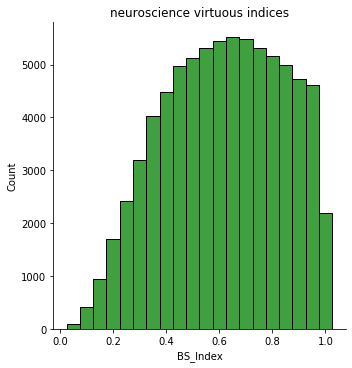

In [8]:
# here we're plotting 'positive indices' i.e. with val = or < 1
p = sns.displot(neuro_df.loc[neuro_df['BS_Index']<=1], x="BS_Index",binwidth=0.05, color='green')
p.set(title='neuroscience virtuous indices')

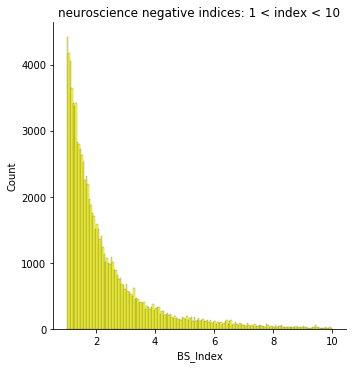

In [9]:
# here we're plotting 'negative indices' i.e. with val > 1 {binwidth .05 from 1 to 10}
# then just a bin for higher than that
p = sns.displot(neuro_df.loc[(neuro_df['BS_Index']>1) & (neuro_df['BS_Index']<10)], x="BS_Index",binwidth=.05, color='yellow')
p.set(title='neuroscience negative indices: 1 < index < 10')

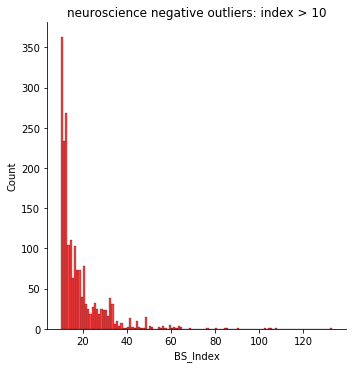

In [10]:
p = sns.displot(neuro_df.loc[(neuro_df['BS_Index']>10)], x="BS_Index",binwidth=1,color='red')
p.set(title='neuroscience negative outliers: index > 10')

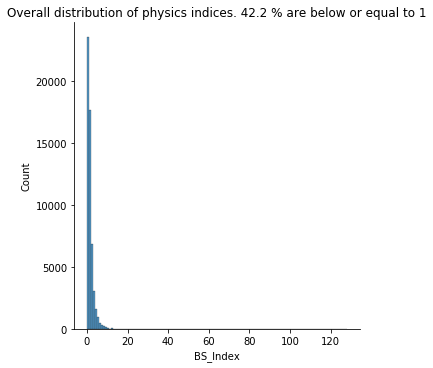

In [11]:
physi_virtuous = np.round((physi_df['BS_Index']<=1).sum()/len(physi_df['BS_Index'])*100,2)

sns.displot(physi_df, x="BS_Index",binwidth=1).set(title='Overall distribution of physics indices. ' + str(physi_virtuous) + ' % are below or equal to 1')

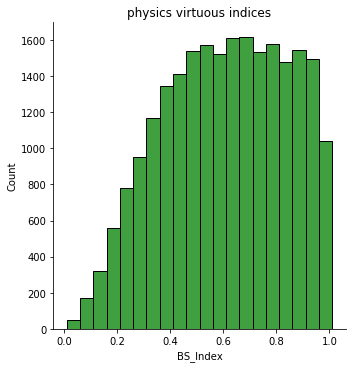

In [12]:
# here we're plotting 'positive indices' i.e. with val = or < 1
p = sns.displot(physi_df.loc[physi_df['BS_Index']<=1], x="BS_Index",binwidth=0.05, color='green')
p.set(title='physics virtuous indices')

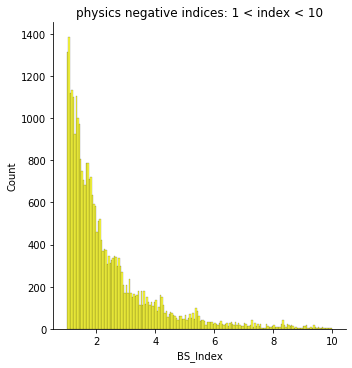

In [13]:
# here we're plotting 'negative indices' i.e. with val > 1 {binwidth .05 from 1 to 10}
# then just a bin for higher than that
p = sns.displot(physi_df.loc[(physi_df['BS_Index']>1) & (physi_df['BS_Index']<10)], x="BS_Index",binwidth=.05, color='yellow')
p.set(title='physics negative indices: 1 < index < 10')

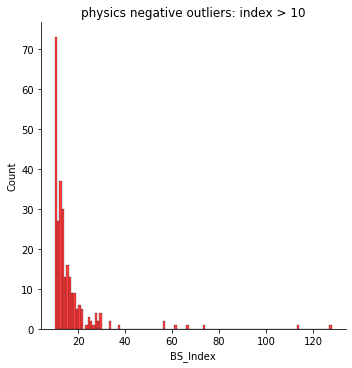

In [14]:
p = sns.displot(physi_df.loc[(physi_df['BS_Index']>10)], x="BS_Index",binwidth=1,color='red')
p.set(title='physics negative outliers: index > 10')